# Data Cleaning

## Imports

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



raw_data_path = "../data/raw_data/"
clean_data_path = "../data/cleaned_data/"

def save_clean_data(df, file_name):
    df.to_csv(clean_data_path + file_name, index=False)



### Wine data

In [55]:
wine_red_data_raw = pd.read_csv(raw_data_path + "winequality/winequality-red.csv", sep=";")
wine_white_data_raw = pd.read_csv(raw_data_path + "winequality/winequality-white.csv", sep=";")

### Retail data

In [56]:
online_retail_data_raw = pd.read_excel(raw_data_path + "retail/Online Retail.xlsx")

### Cup98

In [57]:
cup98_data_raw = pd.read_csv(raw_data_path + "cup98/cup98LRN.txt")

/tmp/ipykernel_6337/381543648.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  cup98_data_raw = pd.read_csv(raw_data_path + "cup98/cup98LRN.txt")


/tmp/ipykernel_6337/3622519153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)


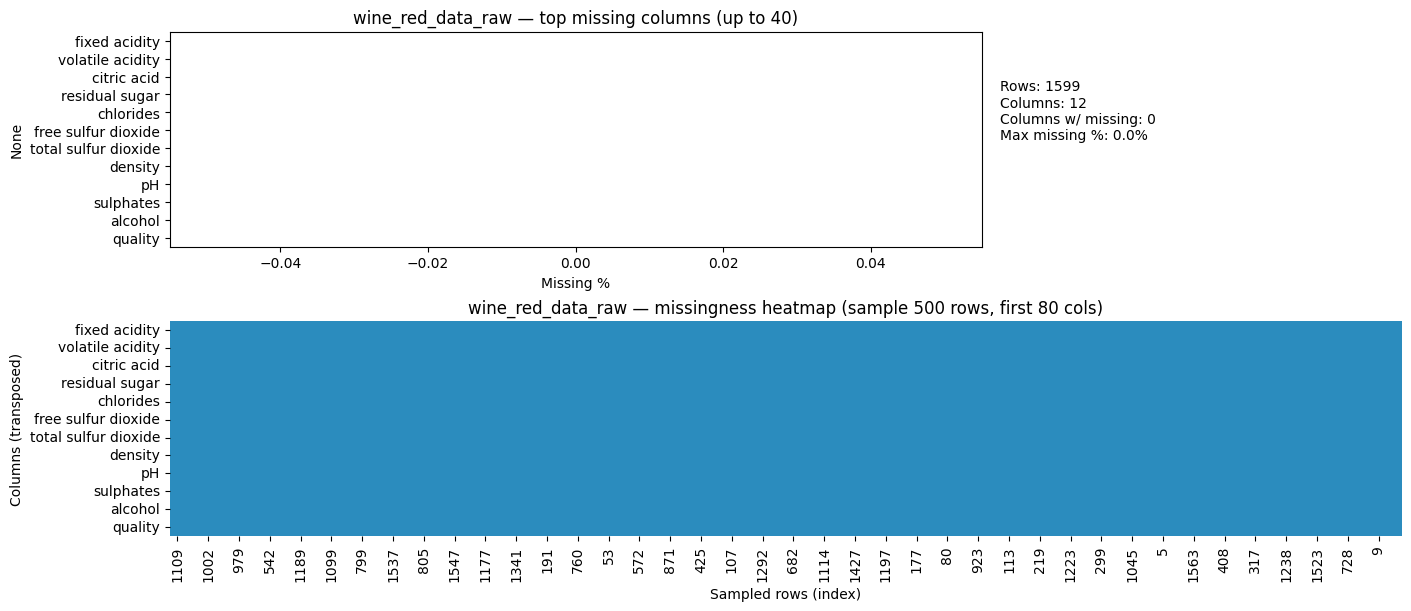

/tmp/ipykernel_6337/3622519153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)


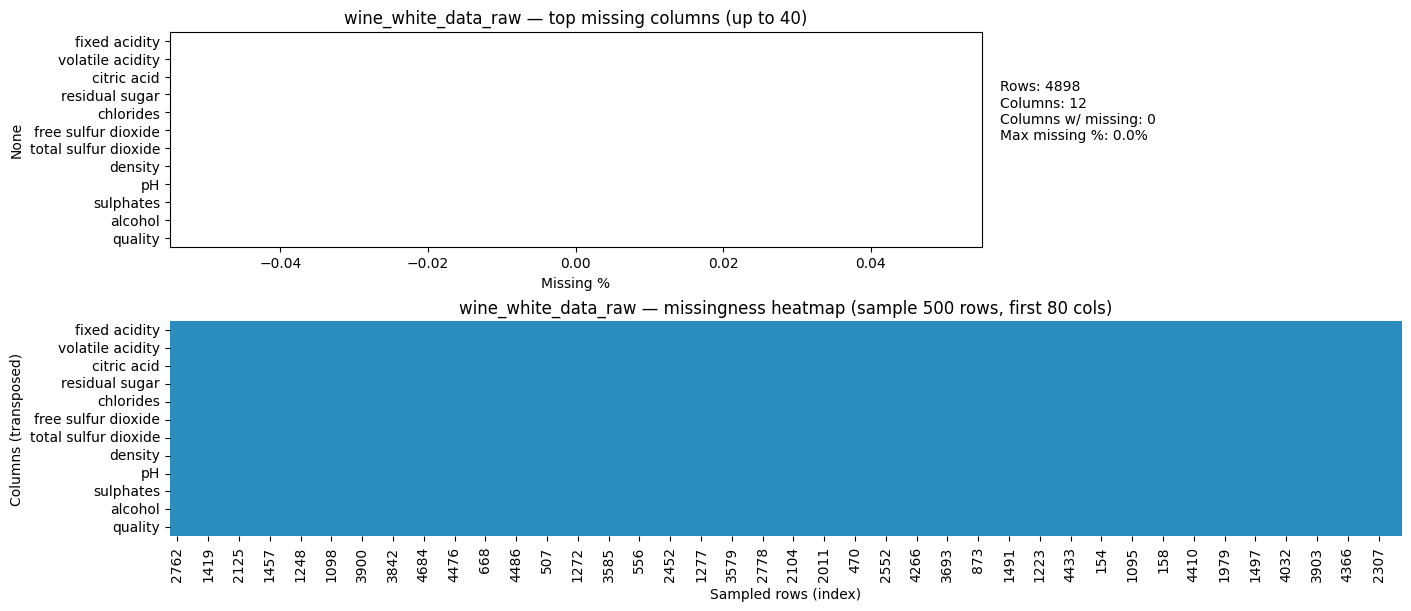

/tmp/ipykernel_6337/3622519153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)


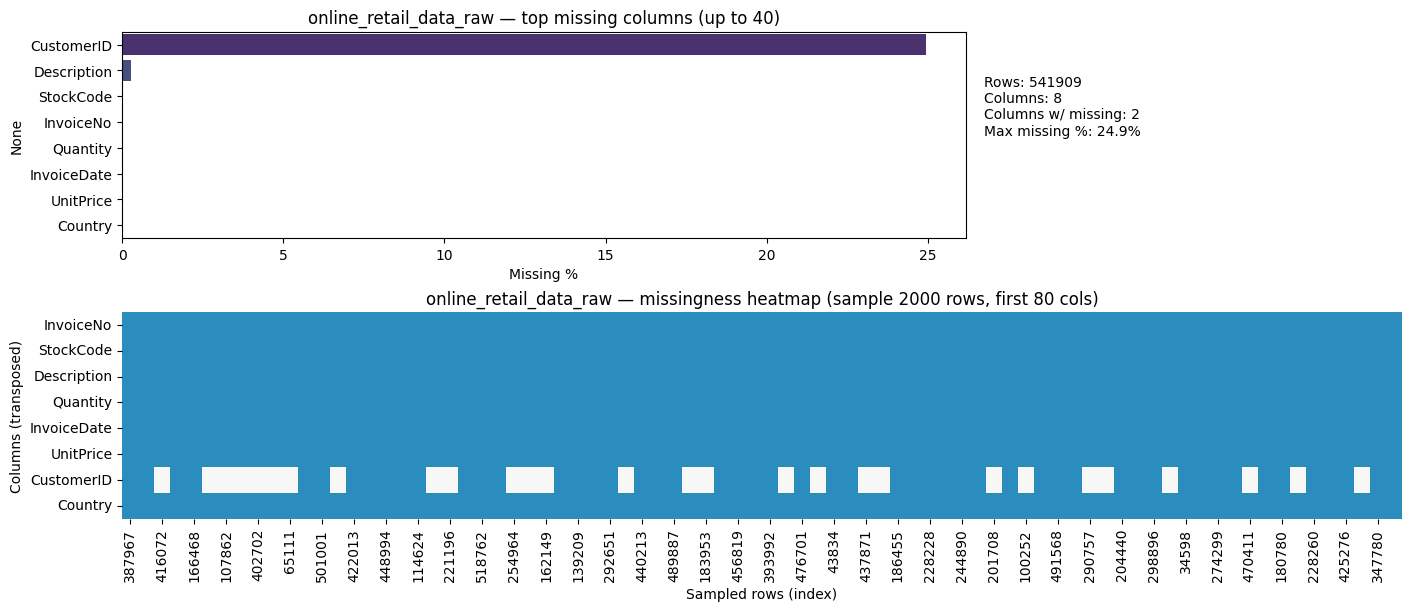

/tmp/ipykernel_6337/3622519153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)


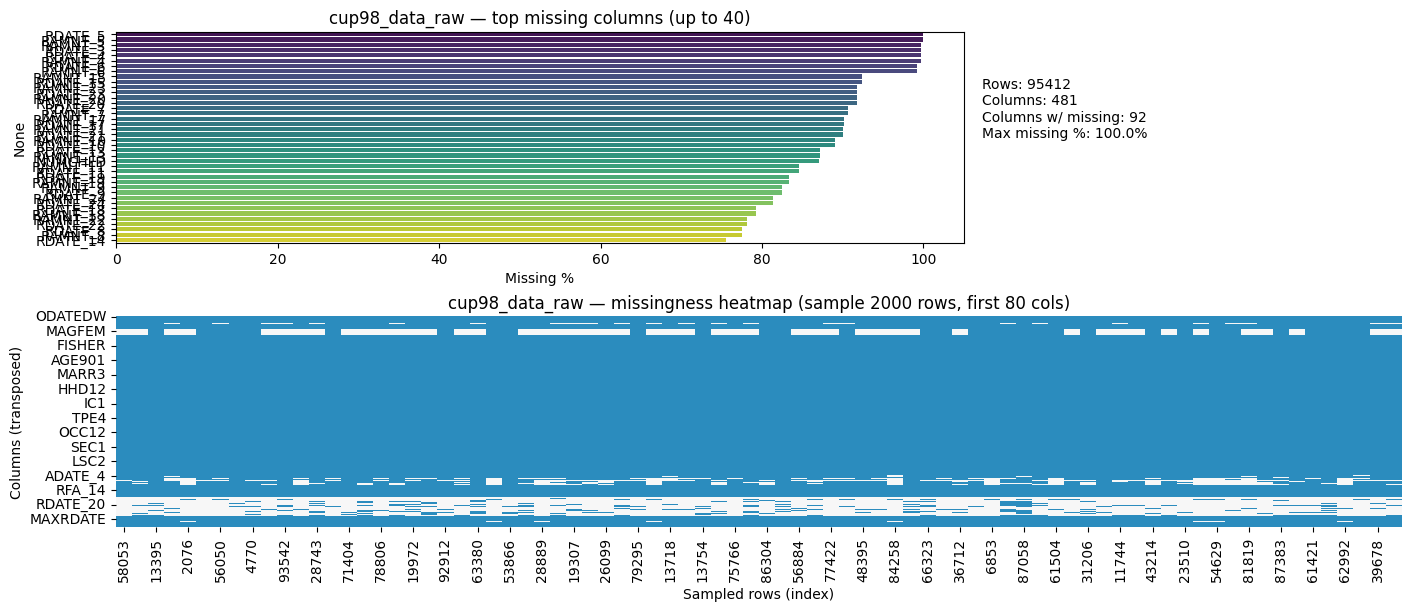

In [58]:





def visualize_missing(df_v, name, sample_n=1000):
    ncols = df_v.shape[1]
    miss_pct = df_v.isna().mean().sort_values(ascending=False) * 100

    fig = plt.figure(constrained_layout=True, figsize=(14, 6))
    gs = fig.add_gridspec(2, 3)

    ax0 = fig.add_subplot(gs[0, :2])
    sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)
    ax0.set_xlabel("Missing %")
    ax0.set_title(f"{name} — top missing columns (up to 40)")

    ax1 = fig.add_subplot(gs[0, 2])
    ax1.axis("off")
    ax1.text(0, 0.5, f"Rows: {len(df_v)}\nColumns: {ncols}\nColumns w/ missing: {(miss_pct>0).sum()}\nMax missing %: {miss_pct.max():.1f}%", 
             fontsize=10)

    # heatmap of missingness for a sample (avoid plotting huge matrices)
    sample = df_v if len(df_v) <= sample_n else df_v.sample(sample_n, random_state=0)
    # create boolean matrix for heatmap (1 = missing)
    miss_mat = sample.isna().astype(int).T  # transpose to have columns on y-axis
    ax2 = fig.add_subplot(gs[1, :])
    # limit number of columns shown in heatmap to avoid clutter
    max_cols_for_heatmap = 80
    if miss_mat.shape[1] > max_cols_for_heatmap:
        miss_mat = miss_mat.iloc[:, :max_cols_for_heatmap]
        ax2.set_title(f"{name} — missingness heatmap (sample {len(sample)} rows, first {max_cols_for_heatmap} cols)")
    else:
        ax2.set_title(f"{name} — missingness heatmap (sample {len(sample)} rows)")
    sns.heatmap(miss_mat, cbar=False, cmap=["#2b8cbe","#f7f7f7"], ax=ax2)
    ax2.set_ylabel("Columns (transposed)")
    ax2.set_xlabel("Sampled rows (index)")

    plt.show()


# Visualize each raw dataframe
visualize_missing(wine_red_data_raw, "wine_red_data_raw", sample_n=500)
visualize_missing(wine_white_data_raw, "wine_white_data_raw", sample_n=500)
visualize_missing(online_retail_data_raw, "online_retail_data_raw", sample_n=2000)
visualize_missing(cup98_data_raw, "cup98_data_raw", sample_n=2000)

## Online_Retail
The majority of the data is missing the customer id, but that we can just drop as it is an identifier

In [59]:
online_retail_data_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [60]:
online_retail_data = online_retail_data_raw.copy()
online_retail_data = online_retail_data.drop(columns=["CustomerID"])
online_retail_data = online_retail_data.drop(columns=["StockCode"])


returns = online_retail_data[online_retail_data['Quantity'] < 0]

returns

,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,Country
141,C536379,Discount,-1,2010-12-01 09:41:00,27.50,United Kingdom
154,C536383,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,United Kingdom
235,C536391,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,United Kingdom
236,C536391,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,United Kingdom
237,C536391,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,United Kingdom
...,...,...,...,...,...,...
540449,C581490,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,United Kingdom
541541,C581499,Manual,-1,2011-12-09 10:28:00,224.69,United Kingdom
541715,C581568,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,United Kingdom
541716,C581569,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,United Kingdom


In [61]:
save_clean_data(online_retail_data, "online_retail_data_clean.csv")

## winequality

In [62]:
wine_red_data_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [63]:
wine_white_data_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [64]:
save_clean_data(wine_red_data_raw, "wine_red_data_clean.csv")
save_clean_data(wine_white_data_raw, "wine_white_data_clean.csv")

## Cup98

In this study: https://lowrank.net/nikos/pubs/empirical.pdf
They did mean imputation for missing values

“KDD98 is from the 1998 KDD-Cup. The task is to predict if a person donates money.
This is the only dataset with missing values. We impute the mean for continuous features and treat missing nominal and boolean features as new values.” (Page 3)

In [65]:
def impute_cup98(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype in ["float64", "int64"]:
            # continuous → mean imputation
            df[col] = df[col].fillna(df[col].mean())
        else:
            # nominal/boolean → new category
            df[col] = df[col].fillna("MISSING")
    return df


/tmp/ipykernel_6337/3622519153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_pct.values[:40], y=miss_pct.index[:40], palette="viridis", ax=ax0)


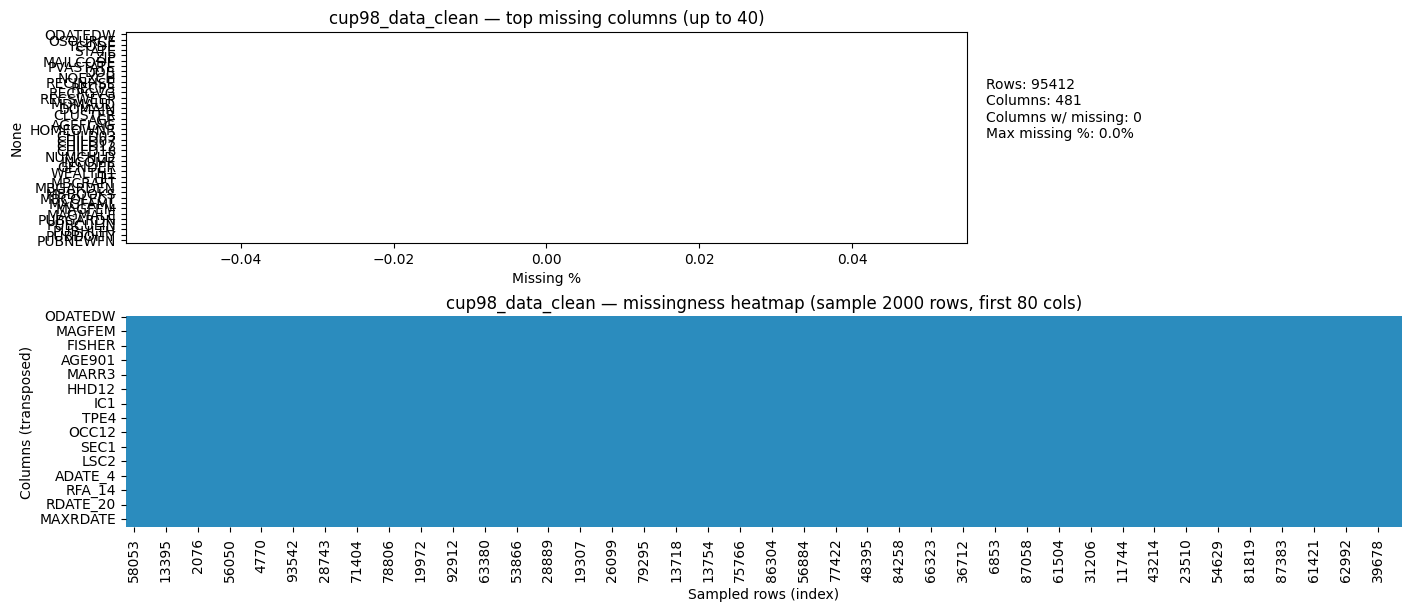

In [66]:

cup98_data_clean = impute_cup98(cup98_data_raw)
visualize_missing(cup98_data_clean, "cup98_data_clean", sample_n=2000)
save_clean_data(cup98_data_clean, "cup98_data_clean.csv")